<a href="https://colab.research.google.com/github/CalculatedContent/xgbwwdata/blob/main/longruns/AnalyzeLongRun_openml_4534.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CalculatedContent/xgbwwdata/blob/main/AnalyzeLongRun_RandomBinary_ModelId.ipynb)


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


In [4]:

# Mount Google Drive when running in Google Colab
try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
except ModuleNotFoundError:
    print('google.colab not available; skipping Drive mount.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
!ls /content/drive/MyDrive/xgbww_runs/*

/content/drive/MyDrive/xgbww_runs/openml_1049_w1w2w7w8w9_alpha:
data_split.npz	metrics.csv  model_latest.json	state.json

/content/drive/MyDrive/xgbww_runs/openml_1049_w7w8_alpha:
data_split.npz	metrics.csv  model_latest.json	state.json

/content/drive/MyDrive/xgbww_runs/openml_1049_w7w8_alpha_wwplots:
data_split.npz	metrics.csv  model_latest.json	state.json  ww_plots

/content/drive/MyDrive/xgbww_runs/openml_random_binary_w1w2w7w8w9_alpha:
openml_1447_w1w2w7w8w9_alpha   openml_45545_w1w2w7w8w9_alpha
openml_1450_w1w2w7w8w9_alpha   openml_45602_w1w2w7w8w9_alpha
openml_1484_w1w2w7w8w9_alpha   openml_45612_w1w2w7w8w9_alpha
openml_40647_w1w2w7w8w9_alpha  openml_45705_w1w2w7w8w9_alpha
openml_41712_w1w2w7w8w9_alpha  openml_46376_w1w2w7w8w9_alpha
openml_41765_w1w2w7w8w9_alpha  openml_46455_w1w2w7w8w9_alpha
openml_41863_w1w2w7w8w9_alpha  openml_467_w1w2w7w8w9_alpha
openml_42172_w1w2w7w8w9_alpha  openml_46865_w1w2w7w8w9_alpha
openml_42638_w1w2w7w8w9_alpha  openml_46922_w1w2w7w8w9_alpha
openml_4

In [31]:
# Checkpoint produced by XGBWW_OpenML_RandomBinary_W1W2W7W8W9_Alpha_Checkpoint.ipynb
MODEL_ID = "4534"  # Set this to the OpenML dataset id used during training

RUN_NAME_BASE = "openml_random_binary_w1w2w7w8w9_alpha"
RUN_NAME = f"openml_{MODEL_ID}_w1w2w7w8w9_alpha"

RUN_NAME_BASE = "openml_w1w2w7w8w9_for_openml_id"
RUN_NAME = f"openml_{MODEL_ID}_w1w2w7w8w9_alpha"

METRICS_PATH = (
    Path('/content/drive/MyDrive/xgbww_runs')
    / RUN_NAME_BASE
    / RUN_NAME
    / f"metrics_openml_{MODEL_ID}.csv"
)

df = pd.read_csv(METRICS_PATH)
display(df.tail(10))
print(f'Read {len(df)} rows from: {METRICS_PATH}')


,round,alpha_w1,alpha_w2,alpha_w7,alpha_w8,alpha_w9,D_w1,D_w2,D_w7,D_w8,...,num_traps_w9,ERG_gap_W1,ERG_gap_W2,ERG_gap_W7,ERG_gap_W8,ERG_gap_W9,train_acc,test_acc,test_logloss,elapsed_min
1297,1307,2.217559,2.263412,2.676961,2.457371,3.147836,0.056177,0.056283,0.041379,0.041664,...,0.0,-70.0,-67.0,46.0,21.0,70.0,0.983039,0.972863,0.070486,998.615296
1298,1308,2.224540,2.220060,2.681162,2.484358,3.170312,0.055374,0.057963,0.046387,0.042570,...,0.0,-73.0,-76.0,47.0,24.0,69.0,0.983039,0.972863,0.070481,999.981357
1299,1309,2.177698,2.200907,2.679446,2.500797,3.095846,0.054478,0.057743,0.042433,0.035352,...,0.0,-80.0,-78.0,47.0,23.0,69.0,0.983039,0.972863,0.070488,1001.374885
1300,1310,2.160996,2.221324,2.620128,2.428057,3.068430,0.057170,0.054809,0.044644,0.040045,...,0.0,-82.0,-74.0,41.0,14.0,67.0,0.983039,0.972863,0.070523,1002.692804
1301,1311,2.180774,2.204254,2.656549,2.490136,3.059898,0.054044,0.057476,0.040098,0.036934,...,0.0,-77.0,-75.0,45.0,18.0,65.0,0.983039,0.972863,0.070453,1004.068817
1302,1312,2.188745,2.212555,2.685862,2.497279,2.903589,0.055325,0.057533,0.040545,0.035993,...,0.0,-76.0,-74.0,45.0,20.0,56.0,0.983039,0.972863,0.070430,1005.411576
1303,1313,2.158746,2.181575,2.661929,2.453205,3.070403,0.056336,0.059441,0.042211,0.036645,...,0.0,-79.0,-77.0,46.0,20.0,65.0,0.983152,0.972863,0.070461,1006.739571
1304,1314,2.182191,2.217323,2.643546,2.423821,2.989611,0.055276,0.058136,0.039115,0.042745,...,0.0,-73.0,-71.0,43.0,15.0,64.0,0.983152,0.972863,0.070447,1008.106907
1305,1315,2.194748,2.227859,2.682322,2.444015,3.243121,0.053135,0.054865,0.044753,0.043891,...,0.0,-76.0,-74.0,48.0,19.0,77.0,0.983152,0.972863,0.070404,1009.496012
1306,1316,2.176114,2.205047,2.605768,2.433641,3.095805,0.052273,0.054281,0.037621,0.038672,...,0.0,-77.0,-75.0,42.0,14.0,66.0,0.983152,0.972863,0.070360,1010.938179


Read 1307 rows from: /content/drive/MyDrive/xgbww_runs/openml_w1w2w7w8w9_for_openml_id/openml_4534_w1w2w7w8w9_alpha/metrics_openml_4534.csv


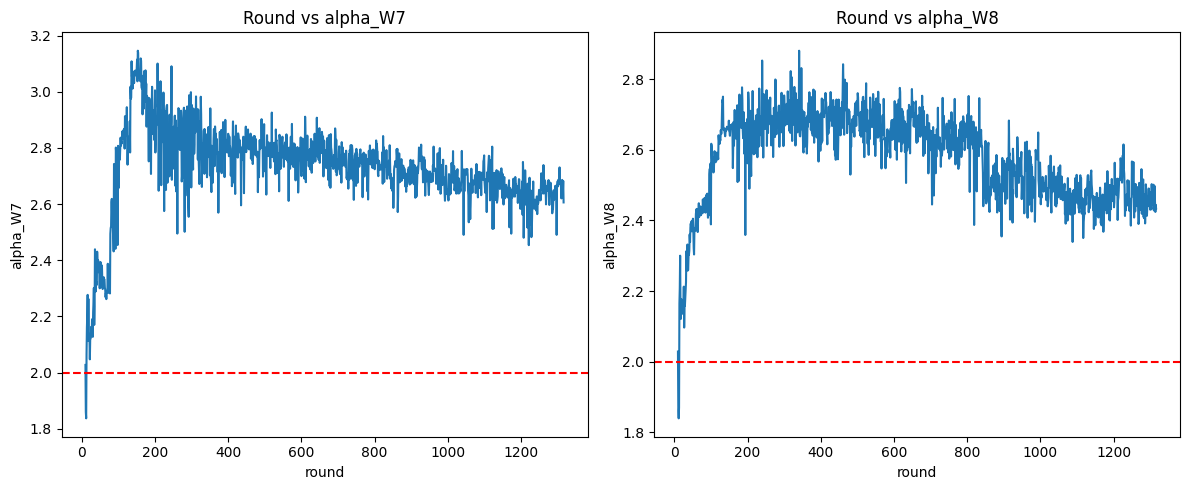

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

ax[0].plot(df['round'], df['alpha_w1'])
ax[0].set_title('Round vs alpha_W1')
ax[0].set_xlabel('round')
ax[0].set_ylabel('alpha_W1')
ax[0].axhline(y=2, color='r', linestyle='--')


ax[1].plot(df['round'], df['alpha_w2'])
ax[1].set_title('Round vs alpha_W2')
ax[1].set_xlabel('round')
ax[1].set_ylabel('alpha_W2')
ax[1].axhline(y=2, color='r', linestyle='--')

plt.tight_layout()
plt.show()


Text(0, 0.5, 'test accuracy')

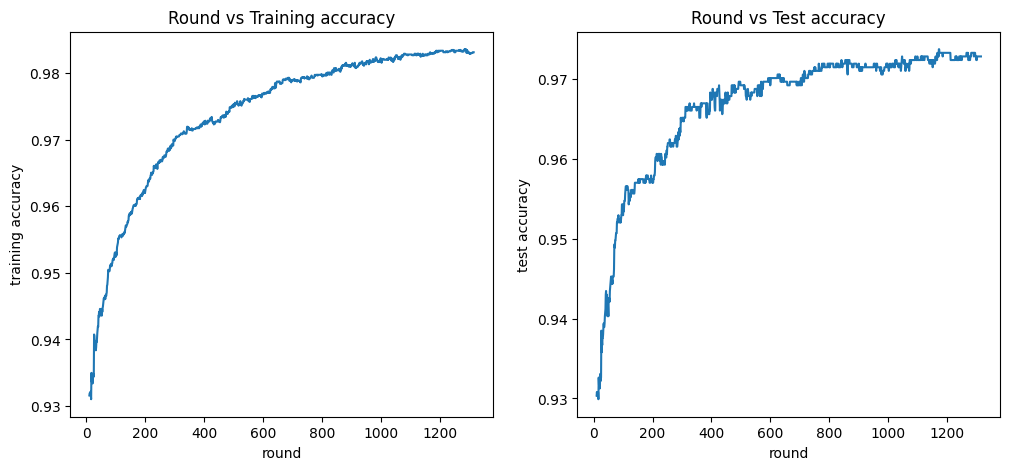

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

ax[0].plot(df['round'], df['train_acc'])
ax[0].set_title('Round vs Training accuracy')
ax[0].set_xlabel('round')
ax[0].set_ylabel('training accuracy')

ax[1].plot(df['round'], df['test_acc'])
ax[1].set_title('Round vs Test accuracy')
ax[1].set_xlabel('round')
ax[1].set_ylabel('test accuracy')


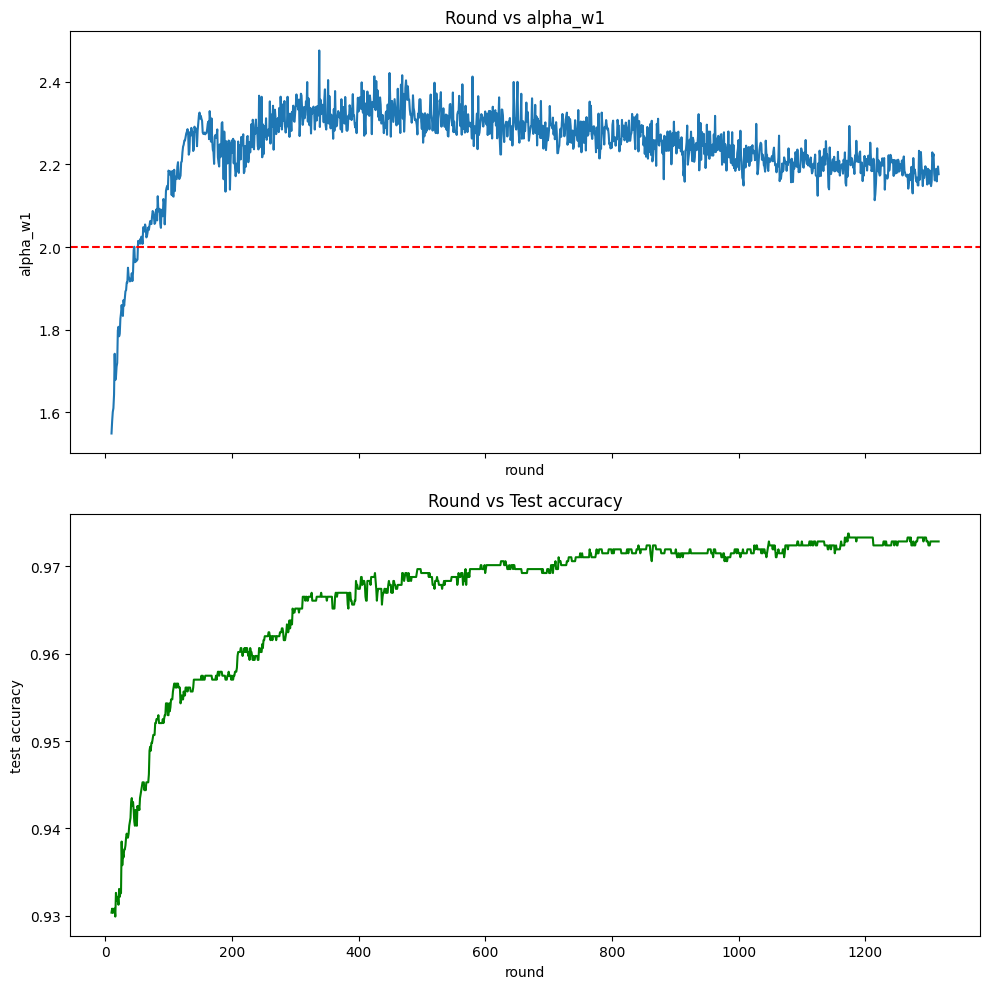

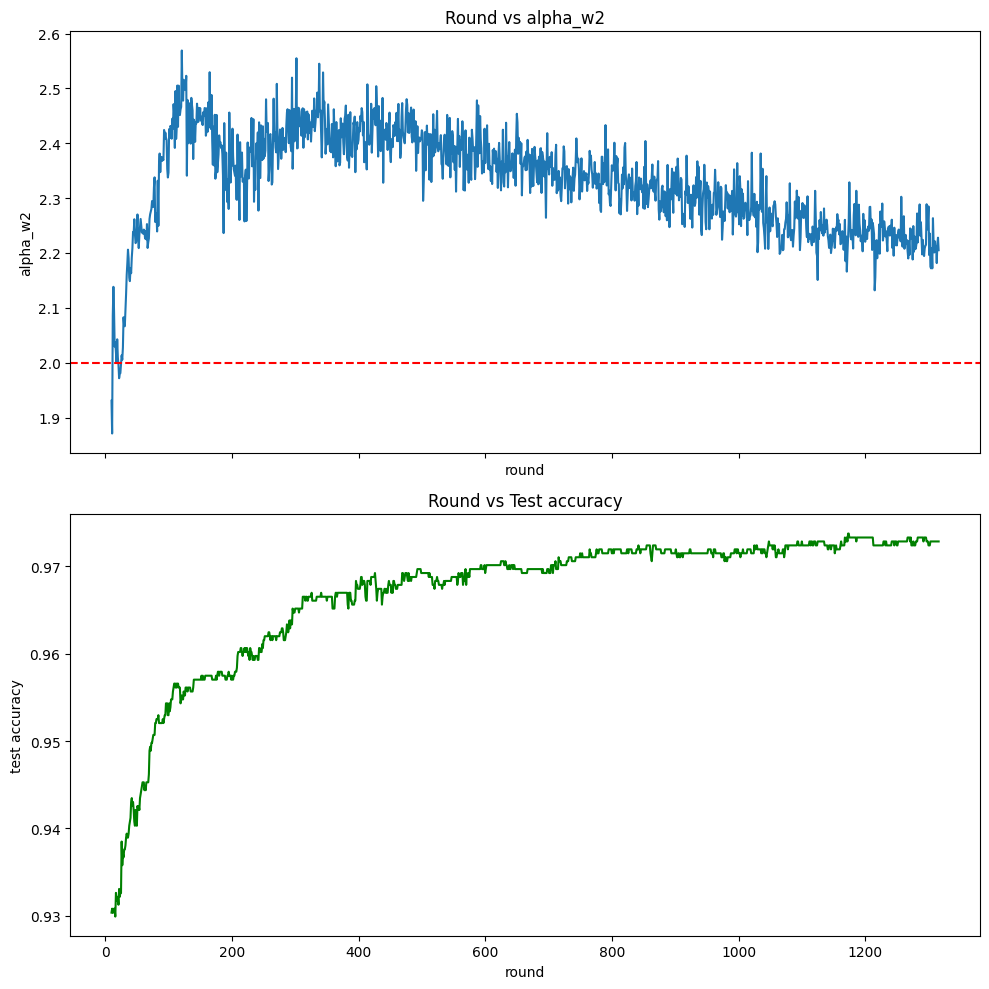

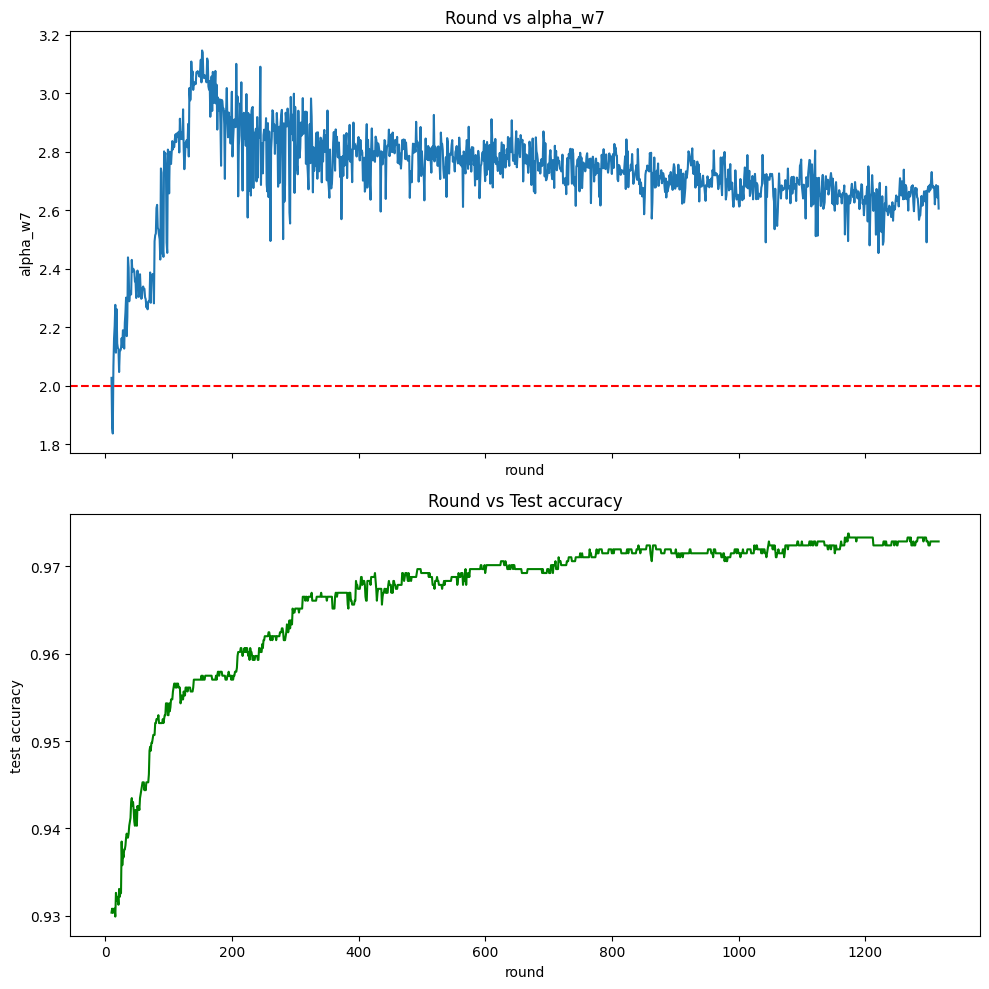

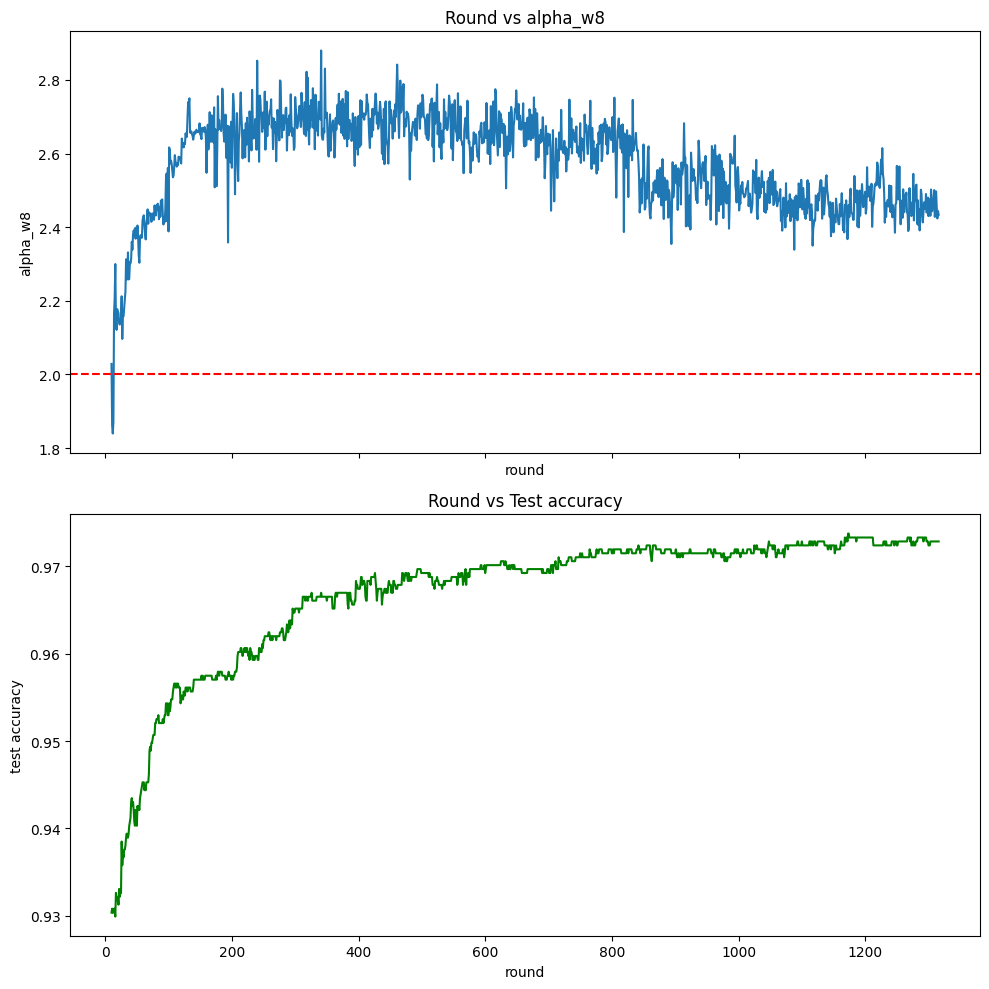

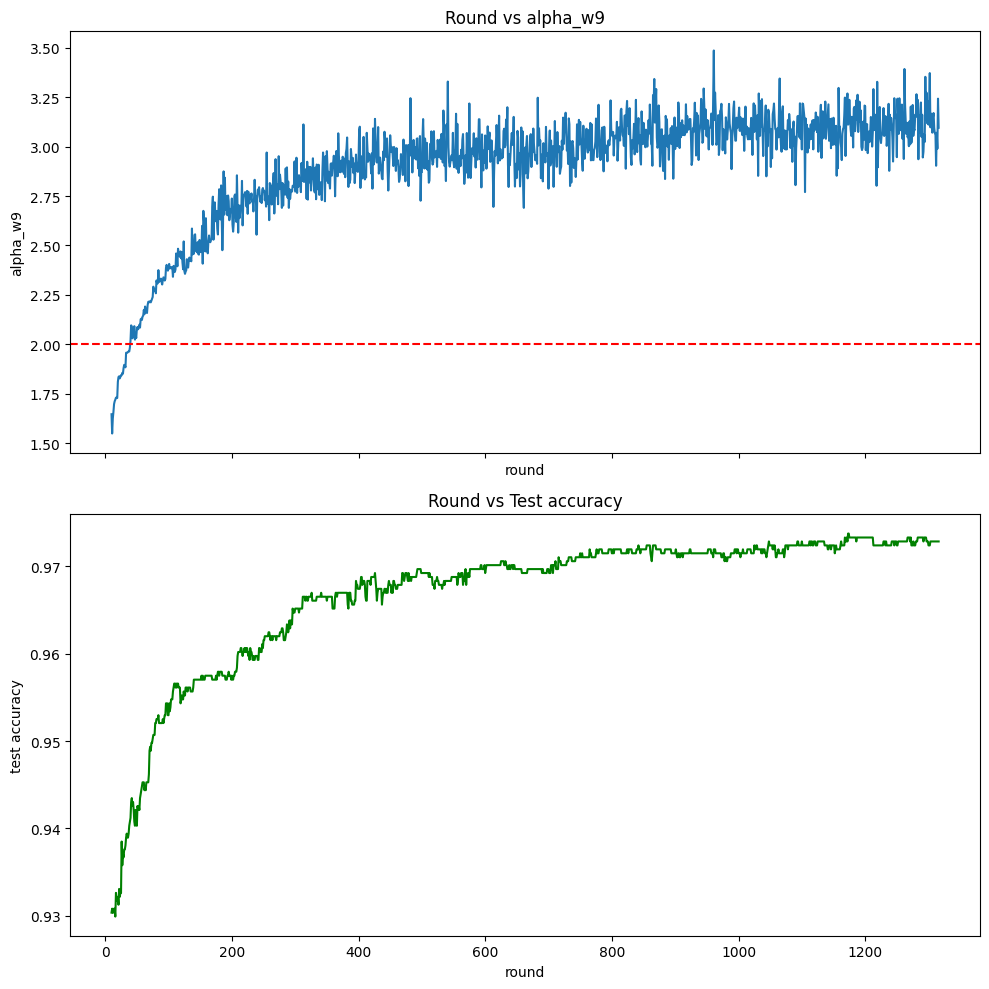

In [34]:

for wnum in [ "alpha_w1","alpha_w2","alpha_w7","alpha_w8","alpha_w9"]:
#for wnum in ["alpha_w7","alpha_w8"]:


  fig, ax = plt.subplots(2,1, figsize=(10,10), sharex=True)


  ax[0].plot(df['round'], df[wnum])
  ax[0].set_title('Round vs '+wnum)
  ax[0].set_xlabel('round')
  ax[0].set_ylabel(wnum)
  ax[0].axhline(y=2, color='r', linestyle='--')
  #ax[0].axvline(x=4800, color='orange', linestyle='--')

  ax[1].plot(df['round'], df['test_acc'],color='green')
  ax[1].set_title('Round vs Test accuracy')
  ax[1].set_xlabel('round')
  ax[1].set_ylabel('test accuracy')
  #ax[1].axvline(x=4800, color='orange', linestyle='--')

  #ax[0].axvline(x=5600, color='orange', linestyle='--')
  #ax[1].axvline(x=5600, color='orange', linestyle='--')


  plt.tight_layout()
  plt.show()

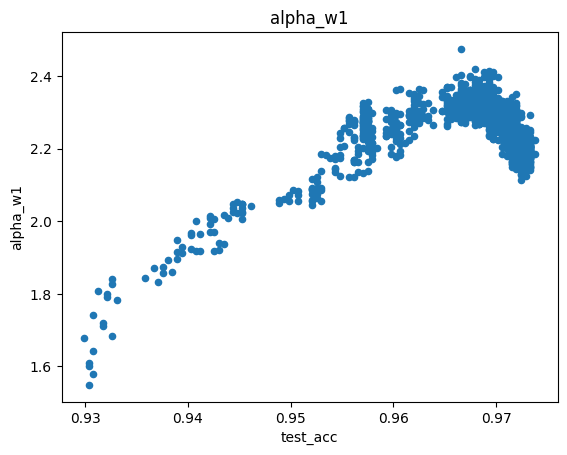

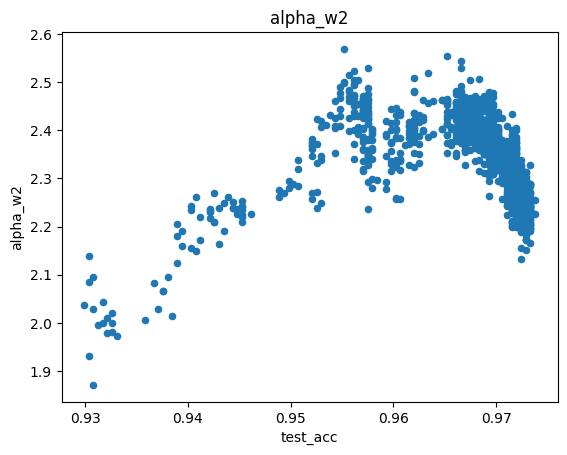

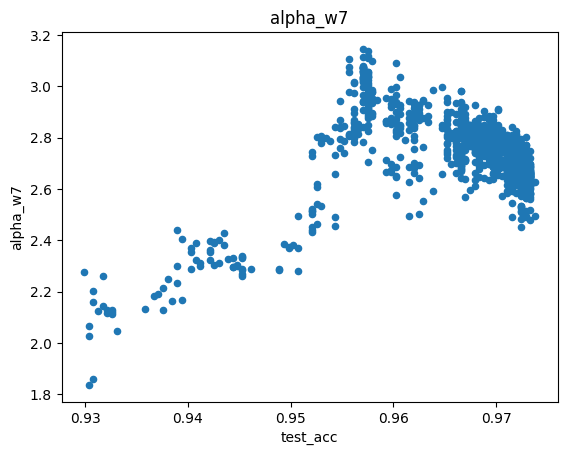

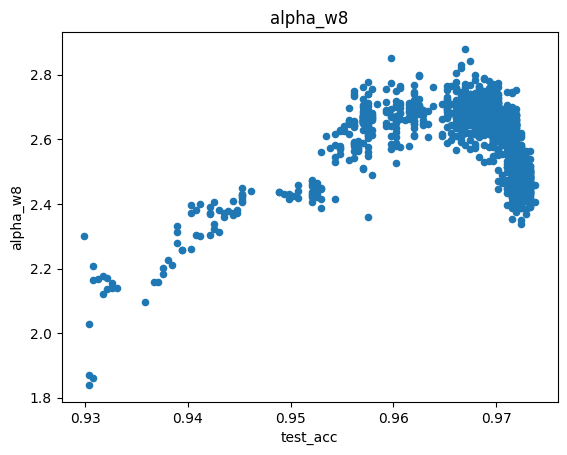

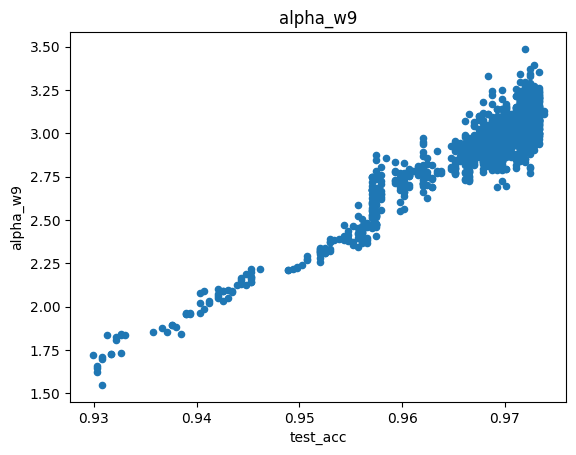

In [35]:
for wnum in [ "alpha_w1","alpha_w2","alpha_w7","alpha_w8","alpha_w9"]:
  df.plot.scatter(x='test_acc',y=wnum,title=wnum )


In [36]:
display(df.num_traps_w1.value_counts())
display(df.num_traps_w2.value_counts())
display(df.num_traps_w7.value_counts())
display(df.num_traps_w8.value_counts())
display(df.num_traps_w9.value_counts())

,count
num_traps_w1,
0.0,1307


,count
num_traps_w2,
0.0,1307


,count
num_traps_w7,
0.0,1306
1.0,1


,count
num_traps_w8,
0.0,1189
1.0,104
2.0,14


,count
num_traps_w9,
0.0,1307


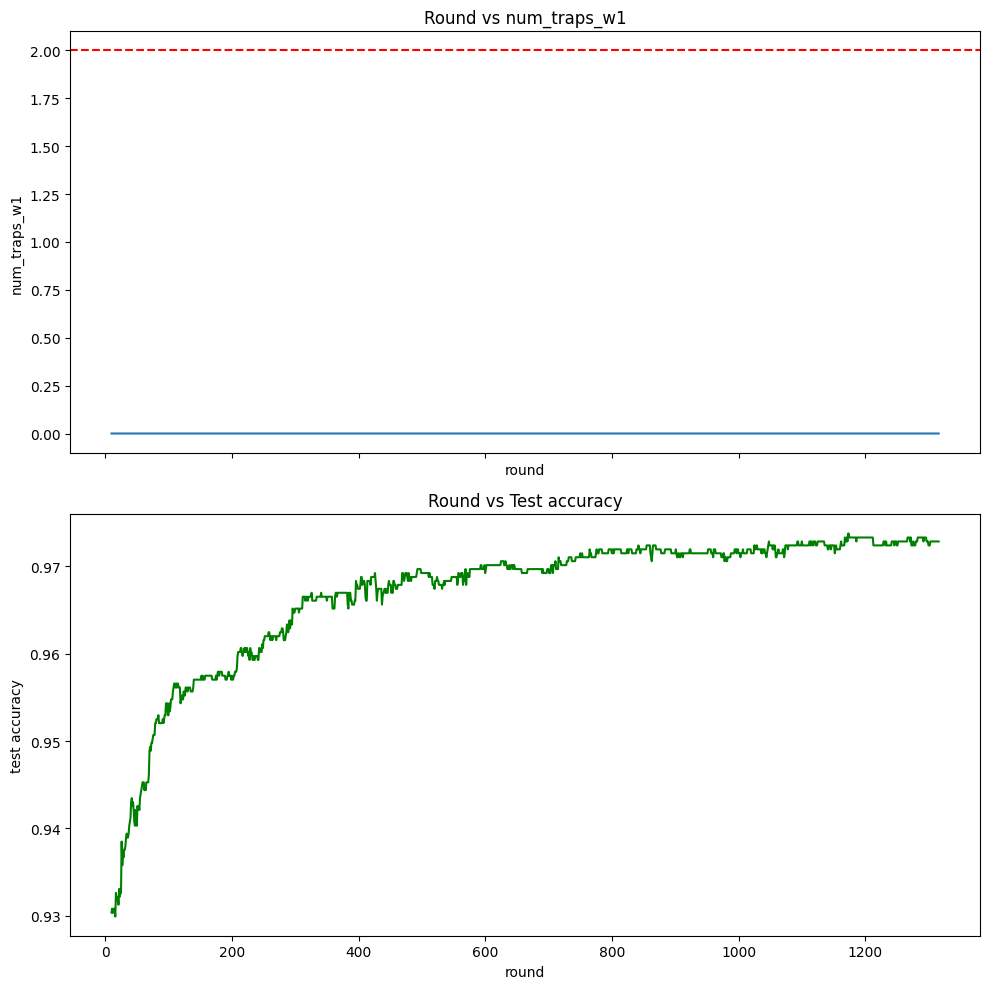

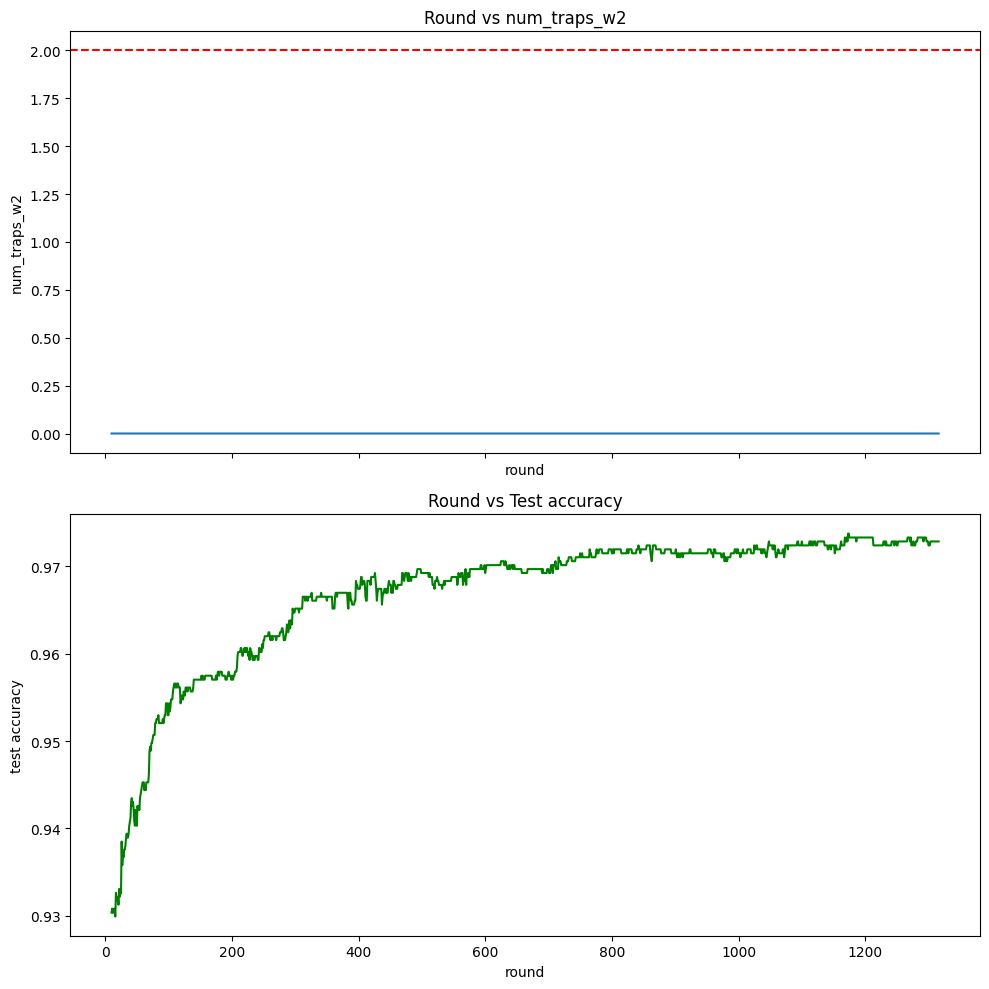

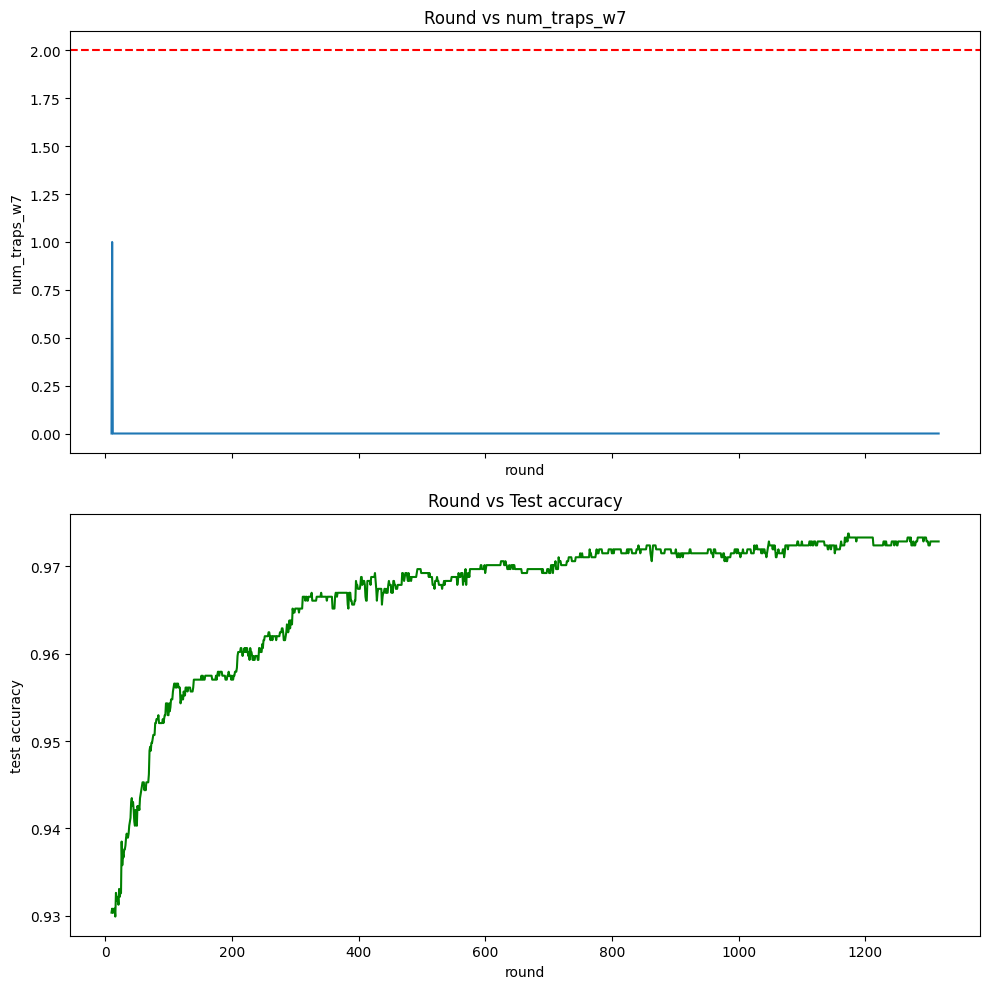

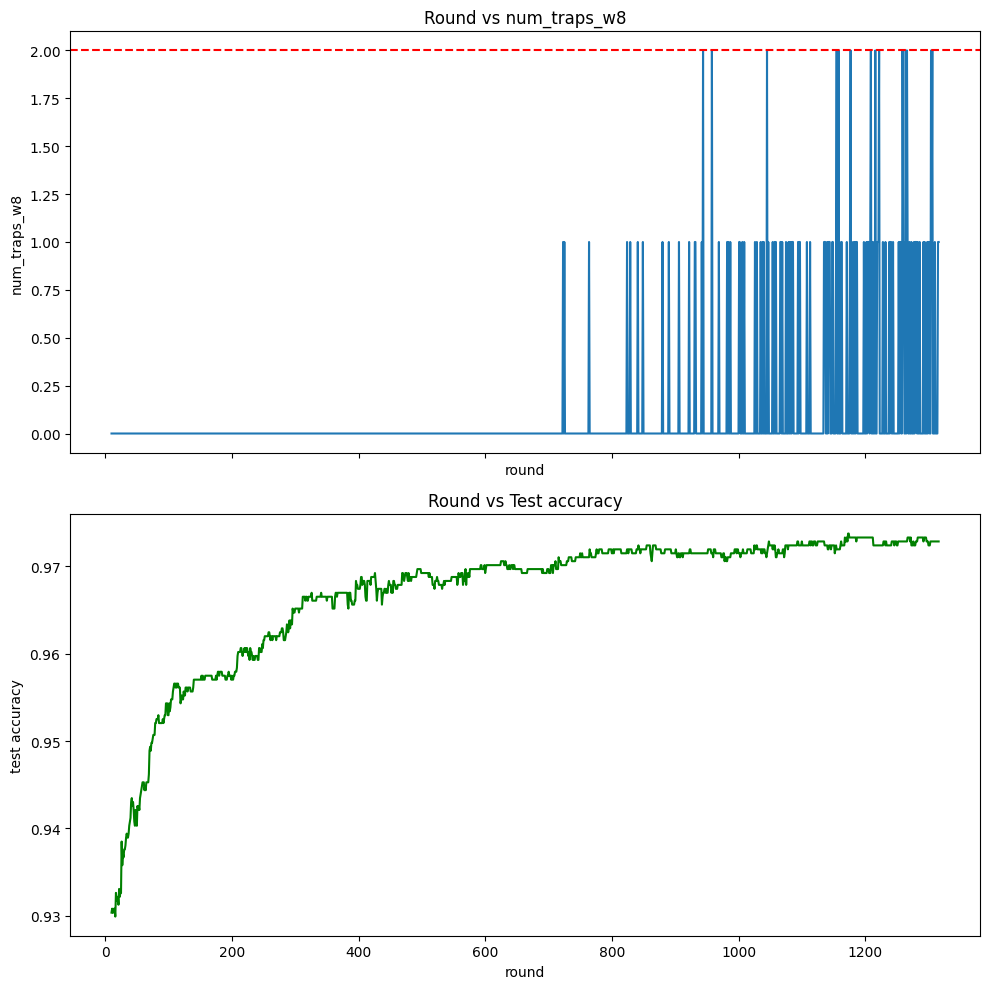

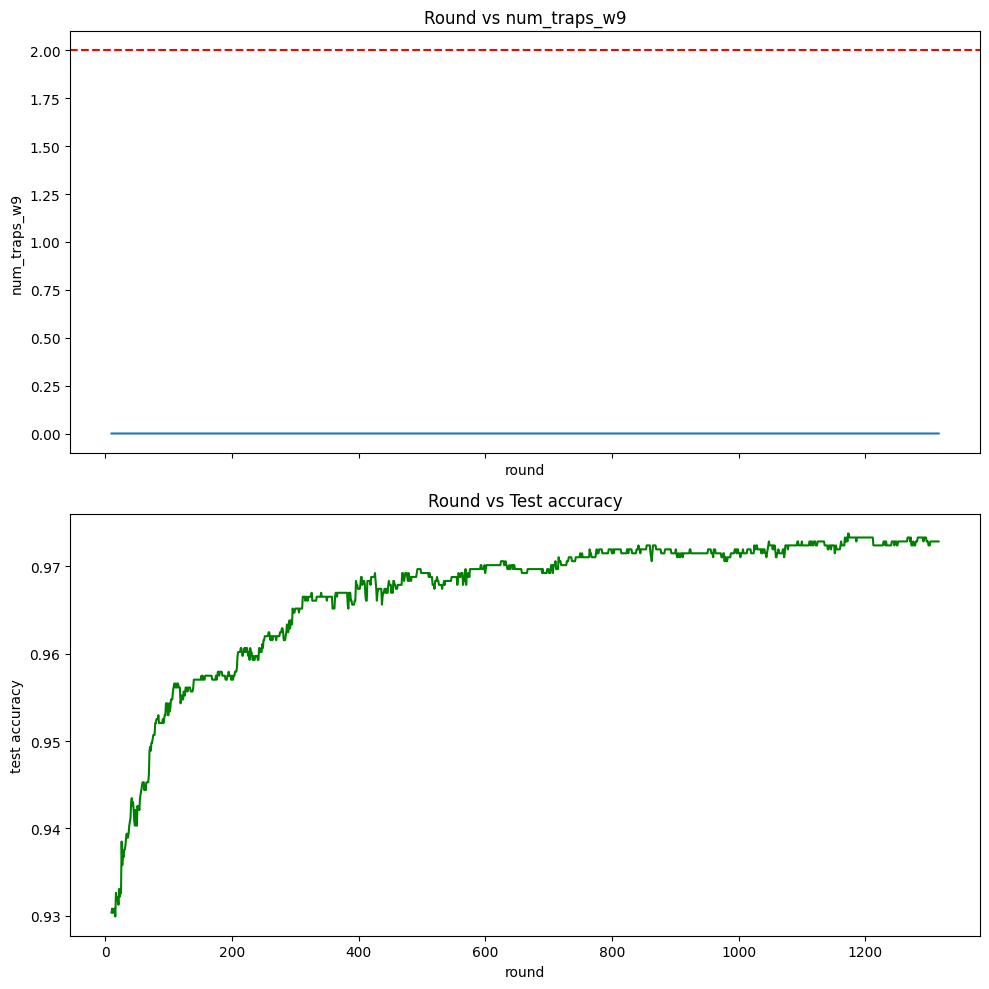

In [37]:

for wnum in [ "num_traps_w1","num_traps_w2","num_traps_w7","num_traps_w8","num_traps_w9"]:

  fig, ax = plt.subplots(2,1, figsize=(10,10), sharex=True)


  ax[0].plot(df['round'], df[wnum])
  ax[0].set_title('Round vs '+wnum)
  ax[0].set_xlabel('round')
  ax[0].set_ylabel(wnum)
  ax[0].axhline(y=2, color='r', linestyle='--')
  #ax[0].axvline(x=4800, color='orange', linestyle='--')

  ax[1].plot(df['round'], df['test_acc'],color='green')
  ax[1].set_title('Round vs Test accuracy')
  ax[1].set_xlabel('round')
  ax[1].set_ylabel('test accuracy')
  #ax[1].axvline(x=4800, color='orange', linestyle='--')

  #ax[0].axvline(x=5600, color='orange', linestyle='--')
  #ax[1].axvline(x=5600, color='orange', linestyle='--')


  plt.tight_layout()
  plt.show()

In [38]:
df.num_traps_w8.sum()

np.float64(132.0)

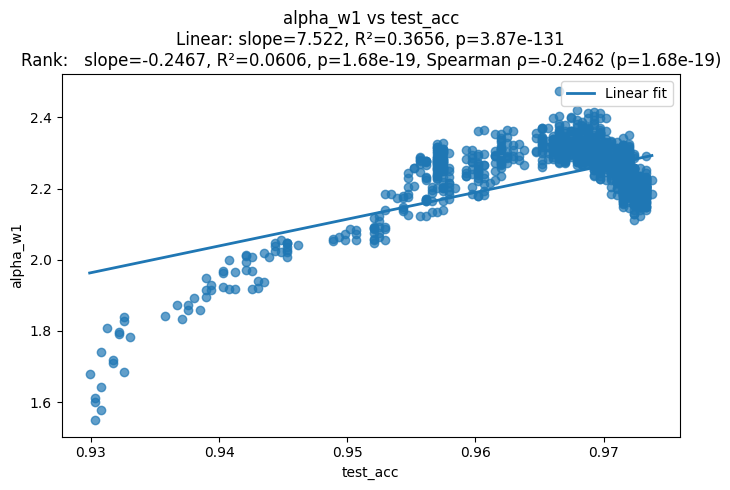

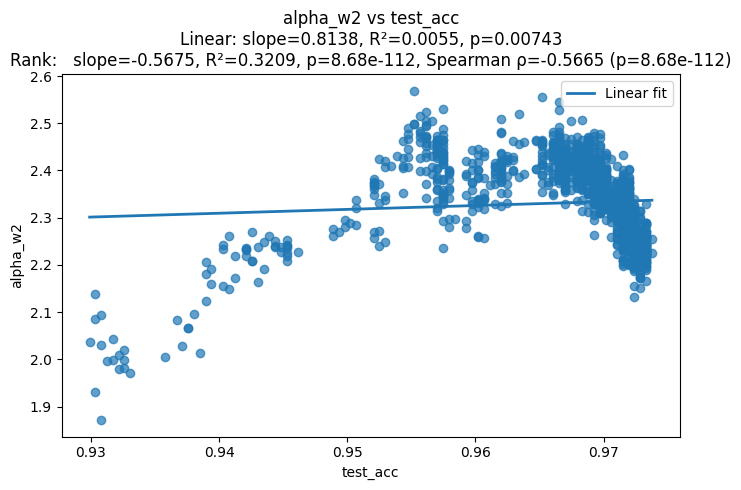

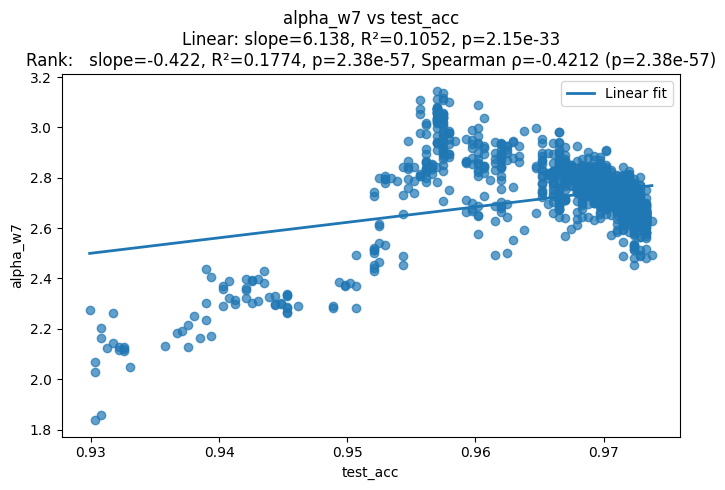

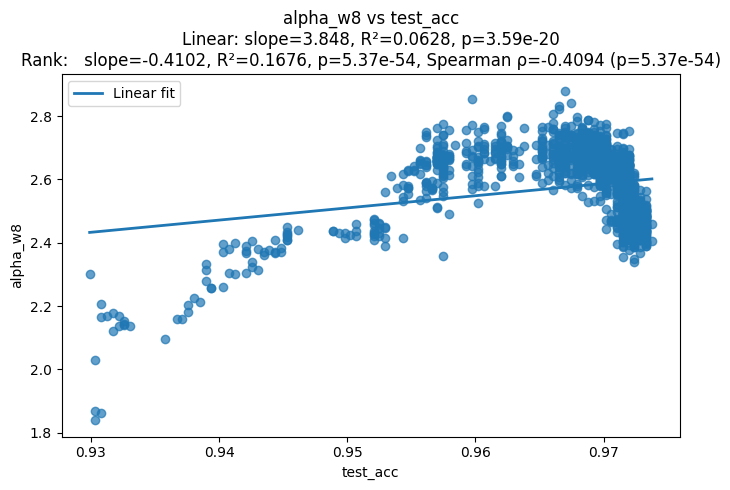

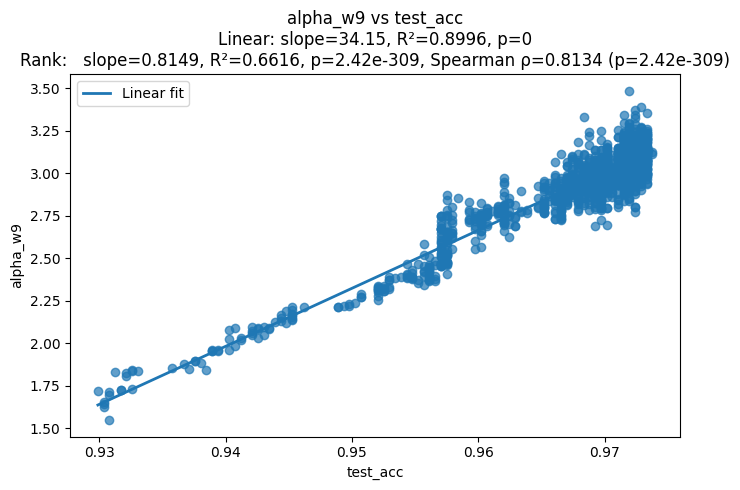

,ycol,n,linear_slope,linear_intercept,linear_r,linear_r2,linear_p,linear_stderr,rank_slope,rank_intercept,rank_r,rank_r2,rank_p,rank_stderr,spearman_rho,spearman_p
0,alpha_w1,1307,7.5218,-5.0316,0.6047,0.3656,0.0000,0.2743,-0.2467,815.3359,-0.2462,0.0606,0.0,0.0269,-0.2462,0.0
1,alpha_w2,1307,0.8138,1.5445,0.0740,0.0055,0.0074,0.3035,-0.5675,1025.1694,-0.5665,0.3209,0.0,0.0229,-0.5665,0.0
2,alpha_w7,1307,6.1384,-3.2085,0.3243,0.1052,0.0000,0.4956,-0.4220,929.9866,-0.4212,0.1774,0.0,0.0252,-0.4212,0.0
3,alpha_w8,1307,3.8480,-1.1456,0.2506,0.0628,0.0000,0.4114,-0.4102,922.2910,-0.4094,0.1676,0.0,0.0253,-0.4094,0.0
4,alpha_w9,1307,34.1467,-30.1149,0.9485,0.8996,0.0000,0.3158,0.8149,121.0272,0.8134,0.6616,0.0,0.0161,0.8134,0.0


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, rankdata, spearmanr

results = []

xcol = "test_acc"
ycols = ["alpha_w1", "alpha_w2", "alpha_w7", "alpha_w8", "alpha_w9"]

for ycol in ycols:
    # keep only finite values
    sub = df[[xcol, ycol]].replace([np.inf, -np.inf], np.nan).dropna()
    x = sub[xcol].to_numpy()
    y = sub[ycol].to_numpy()

    if len(sub) < 3:
        print(f"Skipping {ycol}: not enough data")
        continue

    # -----------------------------
    # 1) simple linear regression
    # -----------------------------
    lr = linregress(x, y)

    # fitted line
    xs = np.linspace(x.min(), x.max(), 200)
    ys = lr.intercept + lr.slope * xs

    # -----------------------------
    # 2) rank regression
    #    regress rank(y) on rank(x)
    # -----------------------------
    xr = rankdata(x, method="average")
    yr = rankdata(y, method="average")
    rr = linregress(xr, yr)

    # also report Spearman as a standard rank-based statistic
    sp = spearmanr(x, y)

    # -----------------------------
    # 3) plot
    # -----------------------------
    plt.figure(figsize=(7, 5))
    plt.scatter(x, y, alpha=0.7)
    plt.plot(xs, ys, linewidth=2, label="Linear fit")

    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.title(
        f"{ycol} vs {xcol}\n"
        f"Linear: slope={lr.slope:.4g}, R²={lr.rvalue**2:.4f}, p={lr.pvalue:.3g}\n"
        f"Rank:   slope={rr.slope:.4g}, R²={rr.rvalue**2:.4f}, p={rr.pvalue:.3g}, "
        f"Spearman ρ={sp.statistic:.4f} (p={sp.pvalue:.3g})"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()

    # save stats
    results.append({
        "ycol": ycol,
        "n": len(sub),

        "linear_slope": lr.slope,
        "linear_intercept": lr.intercept,
        "linear_r": lr.rvalue,
        "linear_r2": lr.rvalue**2,
        "linear_p": lr.pvalue,
        "linear_stderr": lr.stderr,

        "rank_slope": rr.slope,
        "rank_intercept": rr.intercept,
        "rank_r": rr.rvalue,
        "rank_r2": rr.rvalue**2,
        "rank_p": rr.pvalue,
        "rank_stderr": rr.stderr,

        "spearman_rho": sp.statistic,
        "spearman_p": sp.pvalue,
    })

# -----------------------------
# 4) report stats table
# -----------------------------
stats_df = pd.DataFrame(results)
display(stats_df.round(4))